### 0️. Importar Librerias

In [ ]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [ ]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.tsa.stattools import adfuller

from statsmodels.tsa.seasonal import seasonal_decompose

from statsmodels.graphics.tsaplots import (plot_acf,plot_pacf)

from statsmodels.tsa.arima.model import ARIMA

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Para que se muestren todas las columnas al inspeccionar los DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

In [ ]:
from framework import sp_carga_exploracion as sc
from framework import sp_series_temporales as st

### 1️. Cargar DataFrame / modelos

#### Carga

In [ ]:
df = st.cargar_csv(
    '../data/raw/estudiantes_series_temporales.csv',
    parse_dates=['fecha']
)

df.info()

CSV CARGADO
Archivo: ../data/raw/estudiantes_series_temporales.csv
Filas:   36
Columnas: 5
<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha                 36 non-null     datetime64[us]
 1   nota_media            36 non-null     float64       
 2   asistencia_media      36 non-null     float64       
 3   horas_estudio_medias  36 non-null     float64       
 4   tasa_aprobados        36 non-null     float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 1.5 KB


#### check_continuity

In [ ]:
st.check_continuity(
    df,
    'fecha'
)

fecha
31 days    20
30 days    12
28 days     2
29 days     1
Name: count, dtype: int64

✅ No hay anomalías evidentes
✅ No parece haber huecos temporales
✅ La secuencia mensual es coherente

La comprobación de continuidad temporal indica que la serie mantiene una secuencia mensual consistente.

Las diferencias observadas entre fechas corresponden a la duración natural de los meses (28, 29, 30 y 31 días), por lo que no se identifican interrupciones ni huecos temporales significativos.

La serie se considera adecuada para continuar con el análisis temporal.

#### fill_date_gaps

In [ ]:
df = st.fill_date_gaps(
    df,
    'fecha',
    frecuencia='MS'
)

In [ ]:
df.sample(5)

,nota_media,asistencia_media,horas_estudio_medias,tasa_aprobados
fecha,,,,
2023-09-01,70.4,74.2,8.8,0.86
2024-11-01,76.3,80.0,10.6,0.92
2025-08-01,78.9,82.1,11.3,0.95
2024-06-01,74.7,78.4,10.0,0.91
2025-01-01,77.2,80.8,10.9,0.93


La serie se transforma correctamente a frecuencia mensual mediante `MS` (Month Start).

Tras la comprobación de continuidad temporal y la aplicación de `fill_date_gaps()`, no se detectan meses faltantes en la secuencia temporal.

La serie queda preparada para el análisis temporal y puede considerarse completa para el periodo comprendido entre enero de 2023 y diciembre de 2025.
``

In [ ]:
serie = df['nota_media']

st.adf_test(serie)

ADF Statistic: 0.9124
p-value:       0.9932
-> La serie NO es estacionaria (p >= 0.05).
   Valora diferenciarla (aumentar 'd' en ARIMA) antes de modelar.


{'ADF Statistic': np.float64(0.912353455134775),
 'p-value': np.float64(0.9932494429710548),
 'estacionaria': np.False_}

La serie temporal de `nota_media` no es estacionaria.

El resultado del test ADF arroja un p-value de 0.9932, muy superior al umbral habitual de significación (0.05), por lo que no se puede rechazar la hipótesis nula de no estacionariedad.

Este comportamiento era esperable, ya que la serie presenta una tendencia creciente clara a lo largo del periodo analizado.

Antes de entrenar modelos ARIMA será necesario eliminar dicha tendencia mediante diferenciación, lo cual se refleja posteriormente en el parámetro `d` del modelo.

In [ ]:
serie = df.set_index('fecha')['nota_media']

#### descomponer_serie

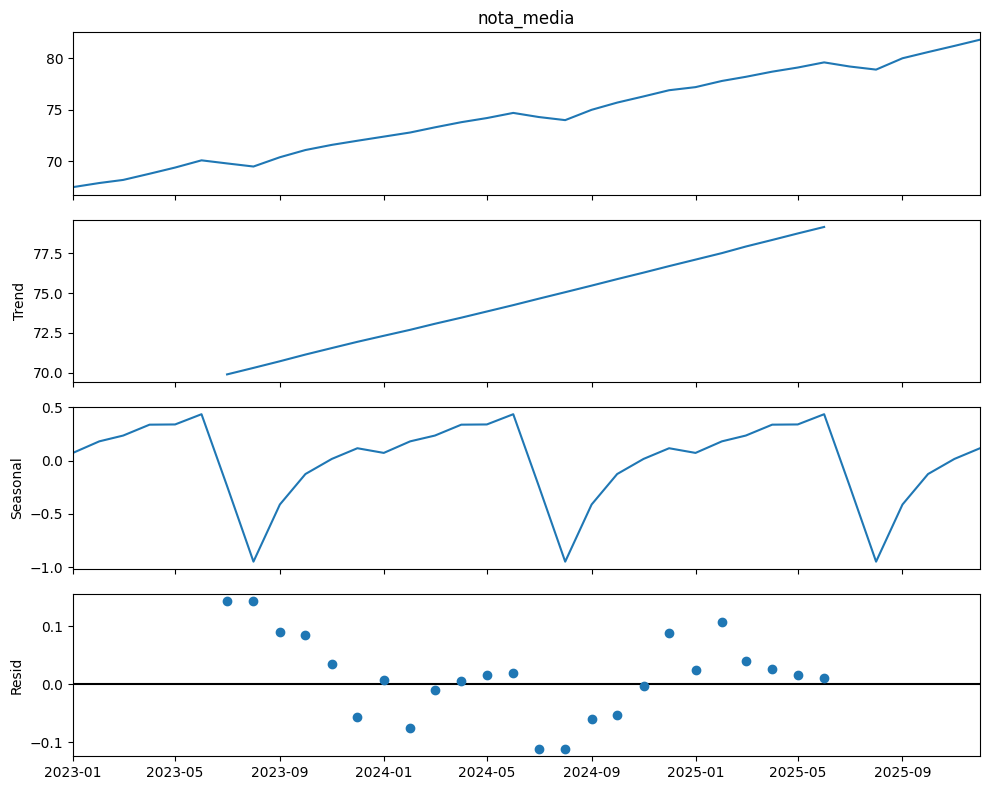

In [ ]:
st.descomponer_serie(
    serie,
    periodo=12
)

Hallazgos

La descomposición temporal permite separar la serie en:

- Tendencia.
- Estacionalidad.
- Residuos.

Se observa una tendencia creciente sostenida en la nota media desde 2023 hasta 2025.

Además, aparece un patrón estacional que se repite aproximadamente cada 12 meses, lo que sugiere la existencia de un componente anual.

Los residuos muestran una variabilidad reducida, indicando que gran parte del comportamiento de la serie queda explicado por la tendencia y la estacionalidad.

Conclusiones

La serie no es estacionaria debido a la fuerte tendencia creciente observada.

La presencia de estacionalidad anual sugiere que modelos estacionales como SARIMA podrían resultar adecuados para el forecasting.

La estructura observada indica una serie relativamente predecible y con bajo nivel de ruido.

#### graficos_autocorrelacion

ValueError: could not broadcast input array from shape (36,) into shape (41,)

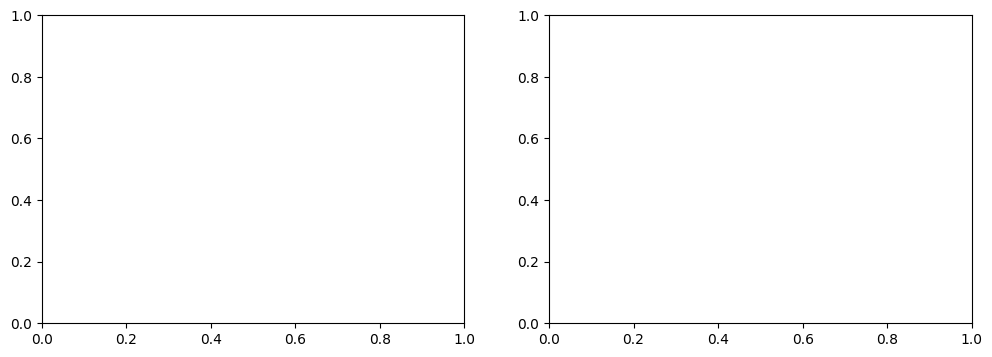

In [ ]:
st.graficos_autocorrelacion(
    serie
)